In [13]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier 
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc

# Notes for supervised modeling

- Loaded and separated the training and testing sets 
- Created x from all features, removing the categorical ones
- Created y from ‘label’ feature (which is the outcome variable)


In [3]:
#loading training set
df_train = pd.read_csv('../data/UNSW_NB15_training-set.csv')
#loading testing set
df_test = pd.read_csv('../data/UNSW_NB15_testing-set.csv')

#X variable for training set 
df_train_x = df_train.drop(['sjit', 'sloss', 'trans_depth', 'dinpkt', 'smean', 
                        'is_ftp_login', 'ct_ftp_cmd', 'proto', 'service', 'state', 'attack_cat', 'label', 
                    'id'], axis=1)
#scaler for x from trainign set
std_scaler = StandardScaler()
df_train_scaled = std_scaler.fit_transform(df_train_x)
#converting back to dataframe to not lose col names (X scaled) 
scaled_train_x = pd.DataFrame(df_train_scaled, columns = df_train_x.columns)

#Y variable
df_train_y = df_train['label'] 

scaled_train_x.describe()

#testing sets 
df_test_x = df_test.drop(['sjit', 'sloss', 'trans_depth', 'dinpkt', 'smean', 
                        'is_ftp_login', 'ct_ftp_cmd', 'proto', 'service', 'state', 'attack_cat', 'label', 
                    'id'], axis=1)
df_test_scaled = std_scaler.transform(df_test_x)
scaled_test_x = pd.DataFrame(df_test_scaled, columns = df_test_x.columns) 

#Y variable for testing data
df_test_y = df_test['label'] 

scaled_test_x.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
count,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,-0.054417,-0.011924,-0.012912,-0.004869,-0.011800,-0.078569,0.013801,0.145724,-0.047277,-0.016792,...,0.022436,0.068204,-0.055761,-0.056498,-0.093929,-0.116238,-0.004740,-0.058575,0.005904,-0.037156
std,0.726895,0.978297,1.048215,0.982131,1.054420,0.898548,0.986144,1.055754,0.954899,0.988310,...,1.036059,1.118173,1.045410,1.042558,1.022792,1.041898,0.910835,1.026733,1.033884,0.842392
min,-0.209775,-0.140982,-0.172047,-0.050473,-0.103923,-0.576819,-1.744196,-0.720406,-0.389973,-0.277208,...,-0.775991,-1.366486,-0.645013,-0.544736,-0.554373,-0.705529,-0.189768,-0.715714,-0.753074,-0.126508
25%,-0.209774,-0.133677,-0.172047,-0.049958,-0.103923,-0.576646,-1.141901,-0.720406,-0.389913,-0.277208,...,-0.682570,-0.318711,-0.645013,-0.544736,-0.554373,-0.705529,-0.189768,-0.715714,-0.660111,-0.126508
50%,-0.207593,-0.104456,-0.153908,-0.047554,-0.102684,-0.560796,0.723268,-0.457978,-0.386909,-0.276335,...,-0.402309,-0.318711,-0.520827,-0.544736,-0.554373,-0.522983,-0.189768,-0.475371,-0.381220,-0.126508
75%,-0.098766,-0.060624,-0.081351,-0.043286,-0.097268,0.094951,0.723268,1.560002,-0.044125,-0.270659,...,0.158213,0.729064,-0.024084,-0.171930,-0.208566,-0.249164,-0.189768,0.005313,0.176560,-0.126508
max,9.049154,77.623772,99.757249,82.092623,101.929787,5.469112,0.732982,1.569051,27.578209,8.321917,...,5.016074,4.920164,6.557761,6.662846,5.843061,4.953391,22.628076,6.374381,4.917694,7.904641


## Random forest 
- Evaluated using accuracy, precision, and recall
- Accuracy: 86.89% but may be inaccurate due to the imbalance in the data set 
- Precision: of all connections that were flagged as an anomalies, how many actually were?
  - 81.54%
- Recall: true positive rate. Of all actual anomalies in the test data, how many were caught by model? 
  - 98.49% 
  - Very high, caught 98% of all attacks 
- Confusion matrix 
  - Chart showing the tp, tn, fp, fn rates 
  - Tp: 44,631
  - Tn: 26,881
  - Fp: 10,000
  - Fn: 721 
- Conclusion: random forest model was able to spot more anomalies accurately than not. Its tp and tn rates combined were much higher than the combination of fp and fn, suggesting that the model was more accurately able to differentiate between true attacks and normal traffic 

0.8696618568721761
0.8159850961626272
0.9855289861466514


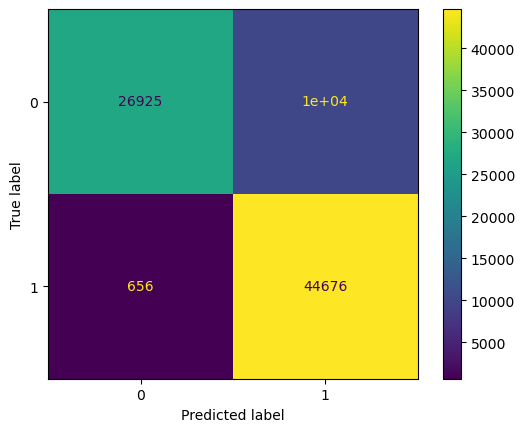

In [4]:
#creating an instance of random forest
rf = RandomForestClassifier() 
#fitting random forest to training data
rf.fit(scaled_train_x, df_train_y)
#model predicting whether it may be an attack or not based off test x
rf_pred = rf.predict(scaled_test_x)
#evaluation using accuracy, actual test y compared to predictions 
accuracy = accuracy_score(df_test_y, rf_pred)

#accuracy
print(accuracy)
#precision 
precision = precision_score(df_test_y, rf_pred)
print(precision)
#recall
recall = recall_score(df_test_y, rf_pred)
print(recall)

#confusion matrix 
cm = confusion_matrix(df_test_y, rf_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

## XGBoost 
XGBoost is a supervised modeling method where it works on trees sequentially to then improve upon the previous tree for better results.
- Evaluated accuracy, precision, and recall 
- Accuracy: 87.20% (again, possibility of inaccuracy because of data set imbalance)
- Precision: 82.23%
- Recall: 97.92%
- Confusion matrix
  - Tp: 44,390
  - Tn: 27,408
  - Fp: 9,592
  - Fn: 942
- Conclusion: XGBoost generated higher results than RF in accuracy and precision, but slightly lower than RF in recall. It’s false negative numbers were 221 points higher than RF. This points to RF performing slightly higher than XGBoost when it comes to flagging real anomalies/attacks. Recall is the most critical in security, therefore Random Forest is preferred. 


0.8720546081717923
0.8223111407506206
0.9792199770581488


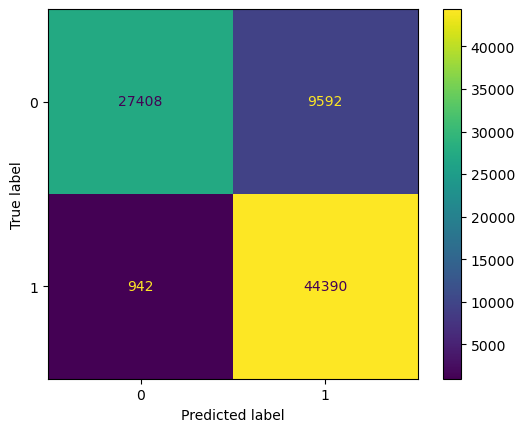

In [5]:
#XGBoost
xgb = XGBClassifier()
#fitting it on training set
xgb.fit(scaled_train_x, df_train_y)
#predictions based off test x
xgb_pred = xgb.predict(scaled_test_x)

#accuracy 
xgb_acc = accuracy_score(df_test_y, xgb_pred)
print(xgb_acc)
#precision
xgb_prec = precision_score(df_test_y, xgb_pred)
print(xgb_prec)
#recall 
xgb_recall = recall_score(df_test_y, xgb_pred)
print(xgb_recall)

xgb_cm = confusion_matrix(df_test_y, xgb_pred) 
ConfusionMatrixDisplay(confusion_matrix=xgb_cm).plot();

# Support Vector Machine 
Support Vector Machine(svm) is a supervised modeling method where the model attempts to find the hyperplane with the widest margins separating points/classes (in this case attacks/anomalies vs normal traffic)
- SVM typically takes a longer computational time on large datasets so the data was sampled to 60,000 rows instead of all 175,341 rows for the sake of time. 
  - Therefore, the results cannot be directly compared to those of RF or XGBoost as they performed on different dataset sizes.
- Evaluated accuracy, precision, and recall 
- Accuracy: 81.38%
- Precision: 74.91%
- Recall: 99.51%
- Confusion matrix
  - Tp: 45,110
  - Tn: 21,898
  - Fp: 15,102
  - Fn: 222
- Conclusion: SVM performed lower than both RF and XGBoost in accuracy and precision, but performed near perfect on recall. In security context, svm would be the preferred model as it captured nearly 100% of attacks, but also caught more fp. However, because SVM was used on a sample of 60,000 rows of the true full dataset, we cannot classify it as the better model. 


SVM Accuracy: 0.8138755283486372
SVM Precision: 0.749186208729157
SVM Recall: 0.9951027971410924


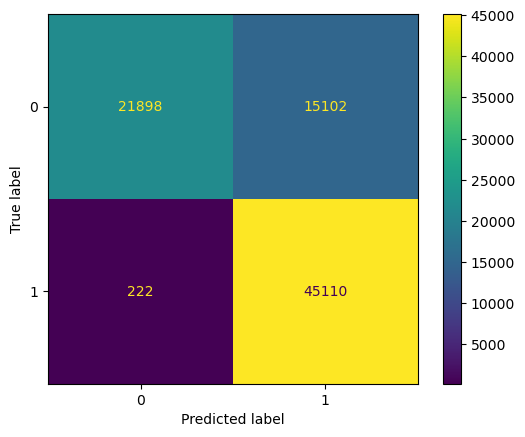

In [29]:
#concatinating x and y dataframes to make sure the rows are aligned
svm_df = pd.concat([scaled_train_x, df_train_y], axis=1)
#sampling 
svm_sample = svm_df.sample(n=60000, random_state=42)

#seperating x and y again based off the sample size
svm_sample_x = svm_sample.drop(['label'], axis=1)
svm_sample_y = svm_sample['label']

#support vector machine
svm = SVC() 
#fitting the svm
svm.fit(svm_sample_x, svm_sample_y) 
#getting predictions 
svm_pred = svm.predict(scaled_test_x)

#accuracy
svm_accuracy = accuracy_score(df_test_y, svm_pred) 
print('SVM Accuracy:', svm_accuracy)
#precision
svm_precision = precision_score(df_test_y, svm_pred) 
print('SVM Precision:', svm_precision)
#recall
svm_recall = recall_score(df_test_y, svm_pred) 
print('SVM Recall:', svm_recall)

#confusion matrix 
svm_cm = confusion_matrix(df_test_y, svm_pred)
ConfusionMatrixDisplay(confusion_matrix = svm_cm).plot()

# SMOTE
SMOTE is a synthetic sampling method used when there is class imbalance in a dataset. It creates synthetic copies of the minority class to create balance. *This step is typically done before modeling, but was simply tested after modeling for comparison as the dataset was meant to have an imbalance.
- Smote was fit to the training x and training y sets and then retrained on RF model for comparison 
- Evaluated accuracy, precision, and recall 
- Accuracy: 87.86%
- Precision: 82.97%
- Recall: 98.06%
- Conclusion: SMOTE on RF was able to slightly increase accuracy and precision, which was expected as the model learned to spot true normal traffic more. However, the recall was slightly lower than regular RF(98.06% vs 98.49%) and that is because SMOTE can sacrifice a little bit of recall for higher precision. In all, the findings were comparable to that of regular RF.

In [28]:
#running smote to balance classes in dataset
smote = SMOTE(sampling_strategy='minority', random_state=42)
smote_x, smote_y = smote.fit_resample(scaled_train_x, df_train_y)
smote_y.value_counts()

#retraining on rf
smote_rf = RandomForestClassifier() 
#fitting rf to smote x and y
smote_rf.fit(smote_x, smote_y)
#calculating predictions
smote_pred = smote_rf.predict(scaled_test_x) 

#accuracy
smote_accuracy = accuracy_score(df_test_y, smote_pred)
print('SMOTE Accuracy: ', smote_accuracy)

#precision 
smote_precision = precision_score(df_test_y, smote_pred)
print('SMOTE Precision: ', smote_precision) 

#recall
smote_recall = recall_score(df_test_y, smote_pred)
print('SMOTE Recall: ', smote_recall) 

SMOTE Accuracy:  0.8782368945246077
SMOTE Precision:  0.829055527596041
SMOTE Recall:  0.9811612106238419


# ROC/AUC
ROC is a curve that measures the true positive rate(tpr) and false positive rate(fpr) of a model. A value closer to 1 indicates a high tpr, a value closer to 0.5 indicates a random guess of the tpr, and a value closer to 0 indicates a low tpr. The AUC is known as the Area Under the Curve and measures the model’s ability to differentiate between classes across all thresholds. 
- The AUC for RF and XGBoost were both measured. *SVM was not measured as it was tested on a limited sample from the dataset as compared to the two other models: 
  - RF: .975
  - XGBoost: .98
- The ROC Plot 
  - Depicted both RF and XGBoost curves in the upper left hand corner, near perfect. It also showed the random guess line running diagonally in the center of the plot, confirming that neither RF or XGBoost are anywhere near that line or below it. 
- Conclusion: Both RF and XGBoost were high in tpr with RF measuring at .975 and XGBoost measuring at .98. While RF had a higher recall rate(98.49%) as compared to XGBoost(97.92%), the recall rate is only measured on a threshold of .5. ROC is measured on all possible thresholds, therefore XGBoost may be preferred in real-world settings as it has more variability. 

RF auc:  0.9753726423193687
XGBoost auc:  0.9813042352994484


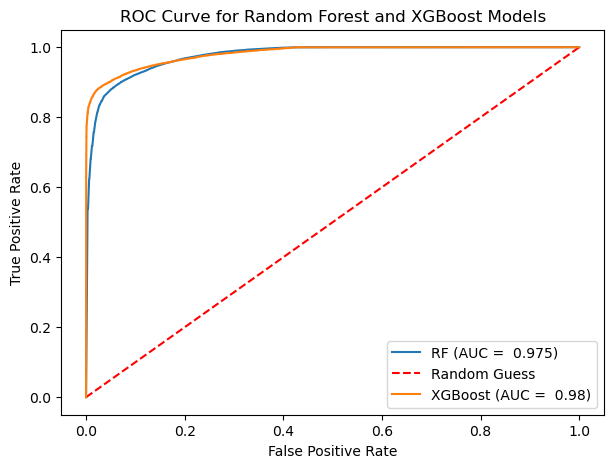

In [27]:
#receiving prediction probabilities (not hard scores) for each model so that roc can run smmothly
rf_proba = rf.predict_proba(scaled_test_x)[:, 1]
xgb_proba = xgb.predict_proba(scaled_test_x)[:, 1]

#receiving false positive rate, true positive rate, and threshold from roc_curve
fpr, tpr, thrhld, = roc_curve(df_test_y, rf_proba)
fpr2, tpr2, thrhld2 = roc_curve(df_test_y, xgb_proba)

#calculating auc 
rf_auc = auc(fpr,tpr)
print('RF auc: ', rf_auc)
xgb_auc = auc(fpr2, tpr2)
print('XGBoost auc: ', xgb_auc)

#creating the roc curve/graph
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr, label= f'RF (AUC = {rf_auc: .3f})')
plt.plot([0,1], [0,1], 'r--', label='Random Guess')
plt.plot(fpr2, tpr2, label = f'XGBoost (AUC = {xgb_auc: .2f})')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve for Random Forest and XGBoost Models')
plt.legend()
plt.show()


# Project Conclusion
The goal of this project was to accurately locate anomalies within a security system of 175,341 network connections. The anomalies would signal an attack on the system as opposed to normal traffic. The project used unsupervised model methods like DBSCAN and Isolation Forest alongside supervised model methods like Random Forest(RF), XGBoost, and Support Vector Machine(SVM) to compare whether these models could accurately classify and flag attacks in the high dimensional system. DBSCAN struggled to identify anomalies due to the data’s high dimensionality while SVM struggled due to computational constraints on large datasets. Contrastingly Isolation Forest, RF, and XGBoost were able to handle the complete dataset and reported accurate results.  Upon further analysis, there appeared to be an imbalance of classes within the dataset of 119,341 attacks versus 56,000 instances of normal traffic. SMOTE was used to create balance within the set, but was not necessary as the dataset was purposely created with imbalance. ROC and AUC were used as the evaluation measure for both RF and XGBoost. While RF measured with a higher recall at a threshold of 0.5, XGBoost measured with a higher true positive rate among all possible thresholds. This leads to the conclusion that XGBoost would be the better recommended model in a real world scenario when identifying true attacks in a security system because it was able to differentiate traffic better across all thresholds. 